<a href="https://colab.research.google.com/github/ECC-ML-DL-STUDY/ECC_MLDL_Study/blob/main/01_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

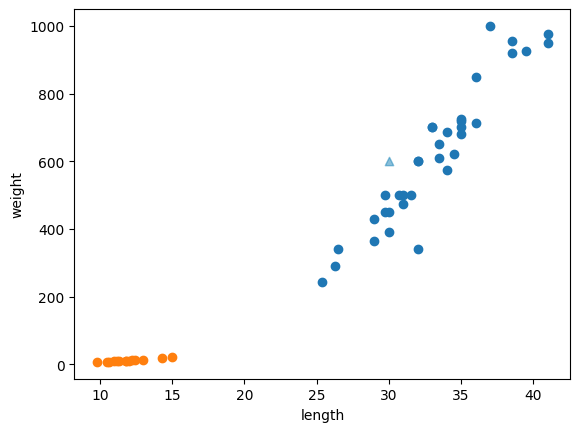

18 0.9795918367346939


0.0

In [ ]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

bream_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]
bream_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]


smelt_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
smelt_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

plt.scatter(bream_length, bream_weight)
plt.scatter(smelt_length, smelt_weight)
plt.xlabel('length')
plt.ylabel('weight')

length = bream_length + smelt_length
weight = bream_weight + smelt_weight

fish_Data = [[l, w] for l, w in zip(length, weight)]
fish_target = [1]*35 + [0]*14

kn = KNeighborsClassifier() #해당 객체에 fish_target, fish_Data를 전달 및 학습시킴 = 훈련!! by. fit()
kn.fit(fish_Data, fish_target)
kn.score(fish_Data, fish_target)

plt.scatter(30, 600, c = '#28B8', marker = '^')
plt.show()

kn.predict([[30, 600]]) #리스트로 두번 감싸주기

kn49 = KNeighborsClassifier(n_neighbors=49)
kn49.fit(fish_Data, fish_target) #일종의 시험공부, 정답을 알려줌
kn49.score(fish_Data, fish_target) #학습한 데이터와 같은 데이터로 성능 평가

for n in range(5, 50):
  kn.n_neighbors = n
  score = kn.score(fish_Data, fish_target)
  if score < 1:
    print(n, score)
    break

#여기서부터는 02-1장
train_input = fish_Data[:35]
train_target = fish_target[:35]
test_input = fish_Data[35:]
test_target = fish_target[35:]

kn.fit(train_input, train_target) #시험문제를 모르는 상태로 시험공부
kn.score(test_input, test_target) #학습한 데이터와 다른 데이터로 성능 평가 -> 샘플링 편향


(49, 2)


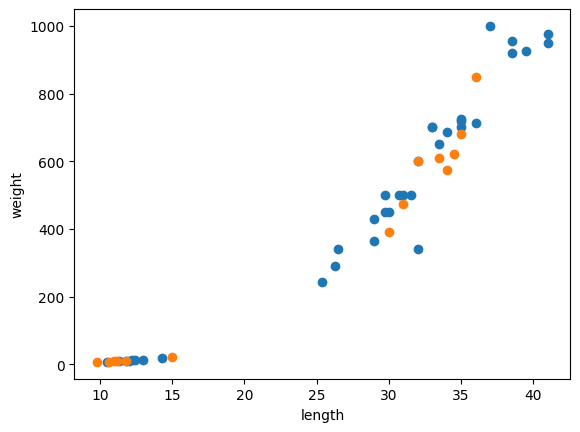

[0 0 1 0 1 1 1 0 1 1 0 1 1 0]


array([0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0])

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

bream_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]
bream_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]


smelt_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
smelt_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

length = bream_length + smelt_length
weight = bream_weight + smelt_weight

fish_Data = [[l, w] for l, w in zip(length, weight)]
fish_target = [1]*35 + [0]*14

input_arr = np.array(fish_Data)
target_arr = np.array(fish_target)
#print(input_arr)
print(input_arr.shape) #샘플 수, 특성 수

kn = KNeighborsClassifier()
#print(input_arr[[1,3]])

#표의 인덱스를 랜덤하게 섞어서 선택하기
index = np.arange(49) #0~48 숫자들 -> 배열
np.random.seed(42) #shuffle() 시 항상 똑같게 섞이도록
np.random.shuffle(index)

'''
np.arange(): 연속된 숫자들을 NumPy 배열 형태로 만들어주는 함수.
-> 파이썬의 range()와 비슷하지만, 결과가 NumPy 배열(array) 로 나온다는 차이가 있음.
np.arange(끝)
np.arange(시작, 끝)
np.arange(시작, 끝, 간격)
'''

#배열
train_input = input_arr[index[0:35]]
train_target = target_arr[index[0:35]]
test_input = input_arr[index[35:]]
test_target = target_arr[index[35:]]

plt.scatter(train_input[:,0], train_input[:,1]) #2차원배열[행,열] -> 모든행,1열(x값) & 모든행,2열(y값)
plt.scatter(test_input[:,0], test_input[:,1])
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

kn.fit(train_input, train_target)
kn.score(test_input, test_target)
print(kn.predict(test_input))
test_target

(36, 2) (13,)
[0. 0. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1.]
[1.]


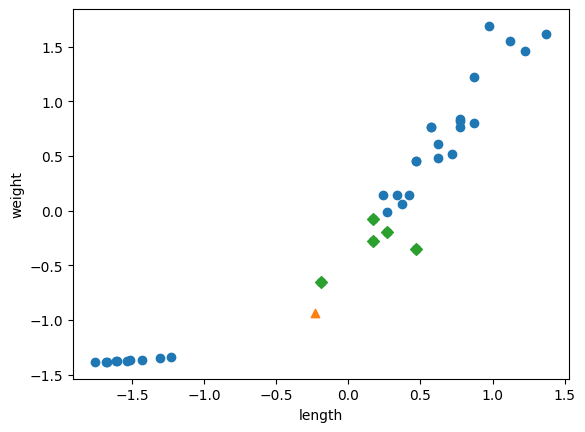

In [32]:
#02-2장
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8,
                10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7,
                7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

fish_data = np.column_stack((fish_length, fish_weight)) #입력 리스트를 하나의 열로, 열 단위로 추가
fish_target = np.concatenate((np.ones(35), np.zeros(14))) #앞 배열 나란히 -> 다음 배열 나란히

train_input, test_input, train_target, test_target = train_test_split(fish_data, fish_target, random_state=42) #입력된 배열 하나 당 두 개의 출력값
print(train_input.shape, test_target.shape)

#샘플링 편향 해소(stratify 매개변수 <- 타깃 데이터, 클래스 비율에 맞게 데이터 분배)
train_input, test_input, train_target, test_target = train_test_split(fish_data, fish_target, stratify=fish_target, random_state=42)
print(test_target)

kn = KNeighborsClassifier()
kn.fit(train_input, train_target)
kn.score(test_input, test_target)
kn.predict([[25, 150]])

'''
plt.scatter(train_input[:,0], train_input[:,1]) #2차원배열[행,열] -> 모든행,1열(x값) & 모든행,2열(y값)
plt.scatter(25, 150, marker='^')
'''
plt.xlabel('length')
plt.ylabel('weight')

distances, indexes = kn.kneighbors([[25, 150]]) #샘플에서 가장 가까운 이웃 찾아줌, 출력값=각 5개 이웃의 거리들, 각 인덱스들
'''
plt.scatter(train_input[indexes, 0], train_input[indexes, 1], marker='D')
plt.xlim((0,1000)) #데이터 표현 기준이 다름 -> 데이터 전처리
'''

mean = np.mean(train_input, axis=0)
std = np.std(train_input, axis=0)
#axis=0이면 열별로 계산, axis=1이면 행별로 계산 후 반환
train_scaled = (train_input - mean)/std

plt.scatter(train_scaled[:,0], train_scaled[:,1])
new = ([25, 150] -mean) / std
plt.scatter(new[0], new[1], marker='^')

kn.fit(train_scaled, train_target)
test_scaled = (test_input-mean)/std
kn.score(test_scaled, test_target)
print(kn.predict([new]))

distances, indexes = kn.kneighbors([new])
plt.scatter(train_scaled[indexes, 0], train_scaled[indexes, 1], marker='D')
plt.show()